# 6 — Ensemble y test de Diebold-Mariano

**Entrada:** `baselines_predicciones.parquet` (notebook 3), `ml_predicciones.parquet`
(notebook 4b), `dl_predicciones.parquet` (notebook 5b)
**Salida:** `comparacion_final.csv`, `ensemble_predicciones.parquet`

Cubre los objetivos 4 (ensemble híbrido + Diebold-Mariano) y cierra la comparación
sistemática del objetivo 2 del Anexo I.

## Aviso metodológico importante

Los baselines del notebook 3 se evaluaron con **walk-forward sobre tramos concretos** y un
corte train/test distinto (`TEST_FRAC=0.4`, multi-tramo). Los modelos de ML y DL usan un
split cronológico simple **60/20/20** sobre el dataset completo. **Las ventanas de test no
tienen por qué coincidir.**

El test de Diebold-Mariano exige comparar errores sobre **exactamente las mismas
observaciones** — no es una comparación de medias, es una comparación pareada. Por eso el
primer paso de este notebook, antes de calcular nada, es construir explícitamente la
**intersección horaria común** a todos los modelos que se quieran comparar, y declarar su
tamaño. Cualquier comparación posterior se hace sobre esa intersección, nunca sobre las
métricas ya calculadas en notebooks anteriores (que usan universos de evaluación distintos).

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

RUTA = Path('.')
plt.rcParams['figure.figsize'] = (11, 4)

def cargar(nombre):
    p = RUTA / nombre
    if not p.exists():
        print(f'AVISO: no existe {nombre}')
        return pd.DataFrame(columns=['ts', 'H', 'modelo', 'real', 'pred'])
    d = pd.read_parquet(p)
    d['ts'] = pd.to_datetime(d['ts'])
    return d

baselines = cargar('baselines_predicciones.parquet')
ml = cargar('ml_predicciones.parquet')
dl = cargar('dl_predicciones.parquet')

todo = pd.concat([baselines, ml, dl], ignore_index=True)

# --- Nombres y horizontes deducidos de los datos, no escritos a mano -------------
# El ganador de DL lo decide el notebook 5 (puede ser LSTM, GRU o Transformer) y el de
# ML el notebook 4. Fijarlos aquí a mano hacía que, si cambiaba el ganador, este
# notebook descartara esas predicciones EN SILENCIO -- sin error, simplemente
# quedaban fuera de la intersección de modelos.
def detectar(sufijo, df, defecto=None):
    hallados = sorted({m for m in df.modelo.unique() if m.endswith(sufijo)})
    if not hallados:
        print(f'AVISO: no hay ningún modelo con sufijo {sufijo}')
        return defecto
    if len(hallados) > 1:
        print(f'AVISO: varios modelos {sufijo} ({hallados}); se usa {hallados[0]}')
    return hallados[0]

MODELO_DL = detectar('(DL)', dl)
MODELO_ML = detectar('(ML)', ml)

# Horizontes: los que están presentes en TODOS los ficheros, no una lista fija.
por_fuente = [set(d.H.unique()) for d in (baselines, ml, dl) if len(d)]
HORIZONTES = sorted(set.intersection(*por_fuente)) if por_fuente else []

print(f'{len(todo)} filas totales, modelos: {sorted(todo.modelo.unique())}')
print(f'DL detectado: {MODELO_DL}   |   ML detectado: {MODELO_ML}')
print(f'horizontes comunes a todos los ficheros: {HORIZONTES}')

436439 filas totales, modelos: ['HARMONIE bruto', 'SARIMA', 'SARIMAX (+HARMONIE)', 'Transformer (DL)', 'XGBoost (ML)']
DL detectado: Transformer (DL)   |   ML detectado: XGBoost (ML)
horizontes comunes a todos los ficheros: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


---
## 1. Intersección horaria común, por horizonte

Se eligen los modelos que van a compararse de verdad —los finalistas de cada familia más los
baselines de referencia— y se calcula sobre cuántas horas **todos** tienen predicción.

In [2]:
MODELOS_COMPARAR = [m for m in ['HARMONIE bruto', 'SARIMAX (+HARMONIE)', MODELO_ML, MODELO_DL]
                    if m is not None]

comunes = {}
for H in HORIZONTES:
    sub = todo[todo.H == H]
    idx_por_modelo = {m: set(sub[sub.modelo == m].ts) for m in MODELOS_COMPARAR
                      if m in sub.modelo.unique()}
    faltantes = [m for m in MODELOS_COMPARAR if m not in idx_por_modelo]
    if faltantes:
        print(f'H={H}: AVISO, sin predicciones para {faltantes}')
    if not idx_por_modelo:
        continue
    comun = set.intersection(*idx_por_modelo.values())
    comunes[H] = sorted(comun)
    print(f'H={H:>3} h:  ' + '  '.join(f'{m}={len(s)}' for m, s in idx_por_modelo.items()) +
         f'   ->  COMÚN={len(comun)}')

for H, horas in comunes.items():
    if len(horas) < 200:
        print(f'\nAVISO: H={H} tiene solo {len(horas)} horas comunes. '
             f'Los resultados de este horizonte serán poco fiables.')

H=  1 h:  HARMONIE bruto=9343  SARIMAX (+HARMONIE)=9343  XGBoost (ML)=4716  Transformer (DL)=4730   ->  COMÚN=4716
H=  2 h:  HARMONIE bruto=9341  SARIMAX (+HARMONIE)=9341  XGBoost (ML)=4706  Transformer (DL)=4722   ->  COMÚN=4706
H=  3 h:  HARMONIE bruto=9339  SARIMAX (+HARMONIE)=9339  XGBoost (ML)=4695  Transformer (DL)=4714   ->  COMÚN=4695
H=  4 h:  HARMONIE bruto=9290  SARIMAX (+HARMONIE)=9290  XGBoost (ML)=4615  Transformer (DL)=4648   ->  COMÚN=4615
H=  5 h:  HARMONIE bruto=9241  SARIMAX (+HARMONIE)=9241  XGBoost (ML)=4546  Transformer (DL)=4581   ->  COMÚN=4546
H=  6 h:  HARMONIE bruto=9192  SARIMAX (+HARMONIE)=9192  XGBoost (ML)=4478  Transformer (DL)=4514   ->  COMÚN=4478
H=  7 h:  HARMONIE bruto=9144  SARIMAX (+HARMONIE)=9144  XGBoost (ML)=4409  Transformer (DL)=4448   ->  COMÚN=4409
H=  8 h:  HARMONIE bruto=9096  SARIMAX (+HARMONIE)=9096  XGBoost (ML)=4341  Transformer (DL)=4381   ->  COMÚN=4341
H=  9 h:  HARMONIE bruto=9048  SARIMAX (+HARMONIE)=9048  XGBoost (ML)=4273  Tran

---
## 2. Tabla de errores pareados

A partir de aquí, **todo** se calcula sobre la intersección común. Se reconstruye el MAE de
cada modelo en ese subconjunto exacto — puede diferir ligeramente de lo publicado en
notebooks anteriores, porque allí el universo de evaluación era distinto.

In [3]:
wide = {}
for H, horas in comunes.items():
    sub = todo[(todo.H == H) & todo.ts.isin(horas) & todo.modelo.isin(MODELOS_COMPARAR)]
    piv = sub.pivot(index='ts', columns='modelo', values='pred').loc[horas]
    real = sub.groupby('ts')['real'].first().loc[horas]
    piv['REAL'] = real
    wide[H] = piv.sort_index()

for H, piv in wide.items():
    print(f'\n--- H={H} h  (n={len(piv)}) ---')
    mae_tab = {m: mean_absolute_error(piv.REAL, piv[m]) for m in MODELOS_COMPARAR if m in piv}
    display(pd.Series(mae_tab).sort_values().rename('MAE').to_frame())


--- H=1 h  (n=4716) ---


,MAE
XGBoost (ML),0.766775
Transformer (DL),0.768850
SARIMAX (+HARMONIE),0.800443
HARMONIE bruto,2.486589



--- H=2 h  (n=4706) ---


,MAE
XGBoost (ML),1.099333
Transformer (DL),1.110009
SARIMAX (+HARMONIE),1.192322
HARMONIE bruto,2.495570



--- H=3 h  (n=4695) ---


...

,MAE
XGBoost (ML),1.506558
Transformer (DL),1.534369
SARIMAX (+HARMONIE),2.523600
HARMONIE bruto,2.551333



--- H=11 h  (n=4135) ---


,MAE
XGBoost (ML),1.516972
Transformer (DL),1.553272
HARMONIE bruto,2.498530
SARIMAX (+HARMONIE),2.641682



--- H=12 h  (n=4065) ---


,MAE
XGBoost (ML),1.520719
Transformer (DL),1.543520
HARMONIE bruto,2.445523
SARIMAX (+HARMONIE),2.714817


,HARMONIE bruto,SARIMAX (+HARMONIE),XGBoost (ML),Transformer (DL)
1,2.487,0.800,0.767,0.769
2,2.496,1.192,1.099,1.110
3,2.503,1.441,1.256,1.284
4,2.539,1.655,1.357,1.357
5,2.559,1.824,1.406,1.428
6,2.575,1.999,1.439,1.436
7,2.581,2.121,1.469,1.481
8,2.609,2.311,1.486,1.497
9,2.589,2.395,1.504,1.539
10,2.551,2.524,1.507,1.534


figura guardada: figuras/ml_vs_baselines_interseccion.png


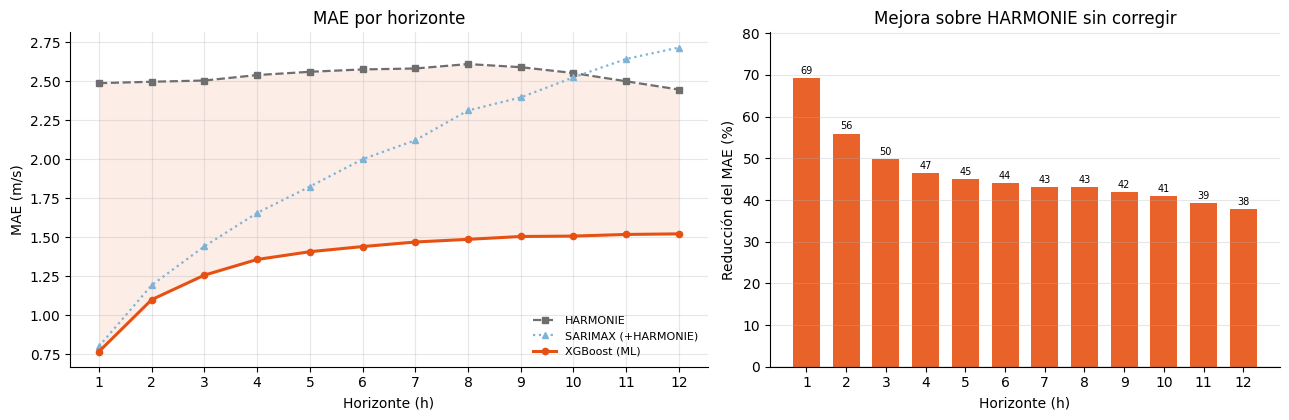

figura guardada: figuras/dl_vs_ml_interseccion.png


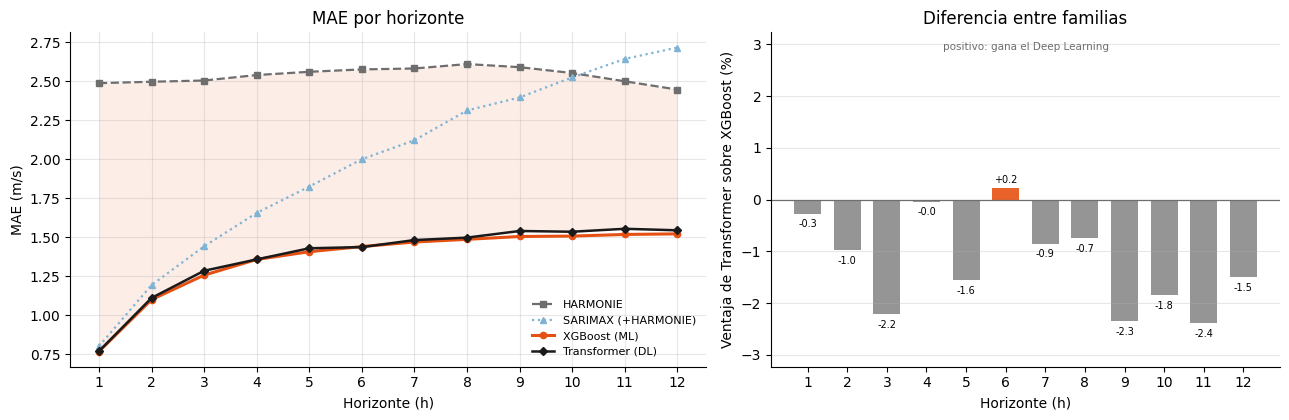

Mejora de XGBoost (%): [69.2, 55.9, 49.8, 46.6, 45.0, 44.1, 43.1, 43.1, 41.9, 41.0, 39.3, 37.8]
Ventaja del DL sobre XGBoost (%): [-0.3, -1.0, -2.2, -0.0, -1.6, 0.2, -0.9, -0.7, -2.3, -1.8, -2.4, -1.5]


In [4]:
# --- Figuras 5.4 y 5.6 recalculadas sobre la intersección horaria común -------
from pathlib import Path
NARANJA, GRIS, AZUL = '#E65113', '#6E6E6E', '#7FB3D5'
ML, DL = MODELO_ML, MODELO_DL

comp = pd.DataFrame({H: {m: mean_absolute_error(p.REAL, p[m]) for m in MODELOS_COMPARAR}
                     for H, p in wide.items()}).T.sort_index()
display(comp.round(3))

ESTILO = {
    'HARMONIE bruto':      dict(color=GRIS,      ls='--', marker='s', lw=1.6, label='HARMONIE'),
    'SARIMAX (+HARMONIE)': dict(color=AZUL,      ls=':',  marker='^', lw=1.6, label='SARIMAX (+HARMONIE)'),
    ML:                    dict(color=NARANJA,   ls='-',  marker='o', lw=2.2, label=ML),
    DL:                    dict(color='#1A1A1A', ls='-',  marker='D', lw=1.8, label=DL),
}

def panel_mae(ax, modelos, destacado):
    for m in modelos:
        ax.plot(comp.index, comp[m], markersize=4.5, **ESTILO[m])
    ax.fill_between(comp.index, comp[destacado], comp['HARMONIE bruto'],
                    color=NARANJA, alpha=.10, lw=0, zorder=0)
    ax.set_xlabel('Horizonte (h)'); ax.set_ylabel('MAE (m/s)')
    ax.set_title('MAE por horizonte'); ax.set_xticks(list(comp.index))
    ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.3)

def barras(ax, valores, ylabel, titulo, simetrico=False):
    colores = [NARANJA if v > 0 else '#8A8A8A' for v in valores]
    b = ax.bar(comp.index, valores, color=colores, alpha=.9, width=.68)
    ax.axhline(0, color=GRIS, lw=.9)
    ax.set_xlabel('Horizonte (h)'); ax.set_ylabel(ylabel); ax.set_title(titulo)
    ax.set_xticks(list(comp.index)); ax.grid(axis='y', alpha=.3)
    if simetrico:
        m = max(abs(valores.min()), abs(valores.max())) * 1.35
        ax.set_ylim(-m, m)
    else:
        ax.set_ylim(0, valores.max() * 1.16)
    for barra, v in zip(b, valores):
        ax.annotate(f'{v:+.1f}' if simetrico else f'{v:.0f}',
                    xy=(barra.get_x() + barra.get_width()/2, v),
                    xytext=(0, 3 if v >= 0 else -10), textcoords='offset points',
                    ha='center', fontsize=7)

def guardar(fig, nombre):
    Path('figuras').mkdir(exist_ok=True)
    for fmt in ('pdf', 'png'):
        fig.savefig(f'figuras/{nombre}.{fmt}', format=fmt, dpi=400, bbox_inches='tight')
    print(f'figura guardada: figuras/{nombre}.png')

# Figura 5.4: XGBoost frente a los baselines
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={'width_ratios': [1.25, 1]})
panel_mae(axes[0], ['HARMONIE bruto', 'SARIMAX (+HARMONIE)', ML], ML)
mejora = 100 * (comp['HARMONIE bruto'] - comp[ML]) / comp['HARMONIE bruto']
barras(axes[1], mejora, 'Reducción del MAE (%)', 'Mejora sobre HARMONIE sin corregir')
for ax in axes:
    for lado in ('top', 'right'): ax.spines[lado].set_visible(False)
plt.tight_layout(); guardar(fig, 'ml_vs_baselines_interseccion'); plt.show()

# Figura 5.6: Transformer frente a XGBoost y a los baselines
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={'width_ratios': [1.25, 1]})
panel_mae(axes[0], ['HARMONIE bruto', 'SARIMAX (+HARMONIE)', ML, DL], DL)
dif = 100 * (comp[ML] - comp[DL]) / comp[ML]
barras(axes[1], dif, f'Ventaja de {DL.split()[0]} sobre XGBoost (%)',
       'Diferencia entre familias', simetrico=True)
axes[1].annotate('positivo: gana el Deep Learning', xy=(.5, .97), xycoords='axes fraction',
                 ha='center', va='top', fontsize=7.5, color=GRIS)
for ax in axes:
    for lado in ('top', 'right'): ax.spines[lado].set_visible(False)
plt.tight_layout(); guardar(fig, 'dl_vs_ml_interseccion'); plt.show()

print('Mejora de XGBoost (%):', mejora.round(1).tolist())
print('Ventaja del DL sobre XGBoost (%):', dif.round(1).tolist())

In [5]:
from sklearn.metrics import recall_score, precision_score, fbeta_score
UMBRAL = 11.5
filas = []
for H, p in wide.items():
    real = p.REAL >= UMBRAL
    for m in MODELOS_COMPARAR:
        pred = p[m] >= UMBRAL
        filas.append({'H': H, 'modelo': m,
                      'pct_positivos': 100 * real.mean(),
                      'recall': recall_score(real, pred),
                      'precision': precision_score(real, pred, zero_division=0),
                      'F2': fbeta_score(real, pred, beta=2),
                      'MAE_viento_fuerte': (p.loc[real, m] - p.loc[real, 'REAL']).abs().mean()})
metricas_umbral = pd.DataFrame(filas)
display(metricas_umbral.pivot(index='modelo', columns='H', values='F2').round(3))
display(metricas_umbral.pivot(index='modelo', columns='H', values='recall').round(3))
display(metricas_umbral.groupby('modelo')[['recall', 'precision', 'F2', 'MAE_viento_fuerte']].mean().round(3))
print('Horas por encima del umbral (%):', metricas_umbral.groupby('H').pct_positivos.first().round(1).tolist())

H,1,2,3,4,5,6,7,8,9,10,11,12
modelo,,,,,,,,,,,,
HARMONIE bruto,0.406,0.399,0.398,0.395,0.388,0.388,0.378,0.384,0.369,0.339,0.297,0.290
SARIMAX (+HARMONIE),0.932,0.898,0.871,0.850,0.823,0.806,0.788,0.755,0.737,0.701,0.656,0.627
Transformer (DL),0.940,0.904,0.889,0.880,0.846,0.856,0.854,0.845,0.843,0.830,0.825,0.800
XGBoost (ML),0.931,0.887,0.864,0.853,0.849,0.850,0.841,0.846,0.842,0.822,0.811,0.797


H,1,2,3,4,5,6,7,8,9,10,11,12
modelo,,,,,,,,,,,,
HARMONIE bruto,0.354,0.348,0.346,0.344,0.337,0.337,0.327,0.333,0.319,0.291,0.253,0.247
SARIMAX (+HARMONIE),0.932,0.896,0.868,0.845,0.816,0.797,0.776,0.739,0.719,0.681,0.634,0.601
Transformer (DL),0.939,0.900,0.884,0.870,0.827,0.839,0.840,0.830,0.827,0.813,0.809,0.779
XGBoost (ML),0.926,0.877,0.849,0.834,0.831,0.833,0.823,0.830,0.826,0.801,0.791,0.776


,recall,precision,F2,MAE_viento_fuerte
modelo,,,,
HARMONIE bruto,0.320,0.981,0.369,4.603
SARIMAX (+HARMONIE),0.775,0.839,0.787,2.066
Transformer (DL),0.846,0.916,0.859,1.382
XGBoost (ML),0.833,0.924,0.849,1.426


Horas por encima del umbral (%): [28.5, 28.6, 28.7, 29.2, 29.6, 30.0, 29.8, 30.3, 29.9, 28.9, 27.5, 26.3]


---
## 3. Ensemble

Tres estrategias, de más simple a más flexible:

* **Media simple** de los finalistas — sin ajustar nada, referencia mínima.
* **Media ponderada** por el inverso del MAE en una porción de calibración separada del test
  final, para no filtrar información de evaluación al ajuste de pesos.
* **Stacking (Ridge)** — un modelo lineal que aprende a combinar las tres predicciones, con
  el mismo cuidado de separar calibración y evaluación.

La intersección común se parte en dos: la primera mitad cronológica para calibrar
pesos/stacking, la segunda para evaluar — igual que un split train/test dentro del propio
conjunto de comparación, para que el ensemble no se beneficie de ver los datos sobre los que
luego se juzga.

In [6]:
FINALISTAS = [m for m in ['SARIMAX (+HARMONIE)', MODELO_ML, MODELO_DL] if m is not None]

ensembles = {}
for H, piv in wide.items():
    disponibles = [m for m in FINALISTAS if m in piv.columns]
    n = len(piv)
    corte = int(n * .5)
    calib, evalu = piv.iloc[:corte], piv.iloc[corte:]

    # Media simple
    pred_media = evalu[disponibles].mean(axis=1)

    # Media ponderada por inverso del MAE en calibración
    mae_calib = {m: mean_absolute_error(calib.REAL, calib[m]) for m in disponibles}
    pesos = {m: 1/mae_calib[m] for m in disponibles}
    suma = sum(pesos.values())
    pesos = {m: p/suma for m, p in pesos.items()}
    pred_pond = sum(evalu[m]*w for m, w in pesos.items())

    # Stacking con Ridge, ajustado SOLO en calibración
    reg = Ridge(alpha=1.0, positive=True)   # positive=True: no tiene sentido un peso negativo
    reg.fit(calib[disponibles], calib.REAL)
    pred_stack = pd.Series(reg.predict(evalu[disponibles]), index=evalu.index)

    ensembles[H] = {
        'evalu': evalu, 'pesos_inv_mae': pesos,
        'coef_stacking': dict(zip(disponibles, reg.coef_)), 'intercepto_stacking': reg.intercept_,
        'pred_media': pred_media, 'pred_pond': pred_pond, 'pred_stack': pred_stack,
    }
    print(f'H={H} h:  pesos inv-MAE: ' +
         ', '.join(f'{m}={w:.3f}' for m, w in pesos.items()))
    print(f'         coefs stacking: ' +
         ', '.join(f'{m}={c:.3f}' for m, c in zip(disponibles, reg.coef_)) +
         f', intercepto={reg.intercept_:.3f}')

H=1 h:  pesos inv-MAE: SARIMAX (+HARMONIE)=0.322, XGBoost (ML)=0.338, Transformer (DL)=0.340
         coefs stacking: SARIMAX (+HARMONIE)=0.138, XGBoost (ML)=0.398, Transformer (DL)=0.468, intercepto=-0.047
H=2 h:  pesos inv-MAE: SARIMAX (+HARMONIE)=0.314, XGBoost (ML)=0.344, Transformer (DL)=0.342
         coefs stacking: SARIMAX (+HARMONIE)=0.111, XGBoost (ML)=0.450, Transformer (DL)=0.455, intercepto=-0.095
H=3 h:  pesos inv-MAE: SARIMAX (+HARMONIE)=0.300, XGBoost (ML)=0.350, Transformer (DL)=0.350
         coefs stacking: SARIMAX (+HARMONIE)=0.116, XGBoost (ML)=0.442, Transformer (DL)=0.458, intercepto=-0.131
H=4 h:  pesos inv-MAE: SARIMAX (+HARMONIE)=0.286, XGBoost (ML)=0.355, Transformer (DL)=0.360
         coefs stacking: SARIMAX (+HARMONIE)=0.153, XGBoost (ML)=0.330, Transformer (DL)=0.542, intercepto=-0.115
H=5 h:  pesos inv-MAE: SARIMAX (+HARMONIE)=0.278, XGBoost (ML)=0.362, Transformer (DL)=0.360
         coefs stacking: SARIMAX (+HARMONIE)=0.208, XGBoost (ML)=0.419, Transfo

,n_eval,SARIMAX (+HARMONIE),XGBoost (ML),Transformer (DL),Ensemble (media),Ensemble (ponderado),Ensemble (stacking)
H,,,,,,,
1,2358,0.829,0.799,0.806,0.789,0.789,0.790
2,2353,1.207,1.125,1.142,1.108,1.108,1.111
3,2348,1.455,1.290,1.345,1.293,1.291,1.285
4,2308,1.681,1.402,1.421,1.403,1.396,1.392
5,2273,1.859,1.437,1.475,1.475,1.461,1.439
6,2239,2.054,1.453,1.472,1.527,1.498,1.460
7,2205,2.167,1.459,1.506,1.571,1.532,1.475
8,2171,2.328,1.473,1.507,1.602,1.545,1.494
9,2137,2.410,1.491,1.549,1.649,1.584,1.514


figura guardada: figuras/ensembles.pdf


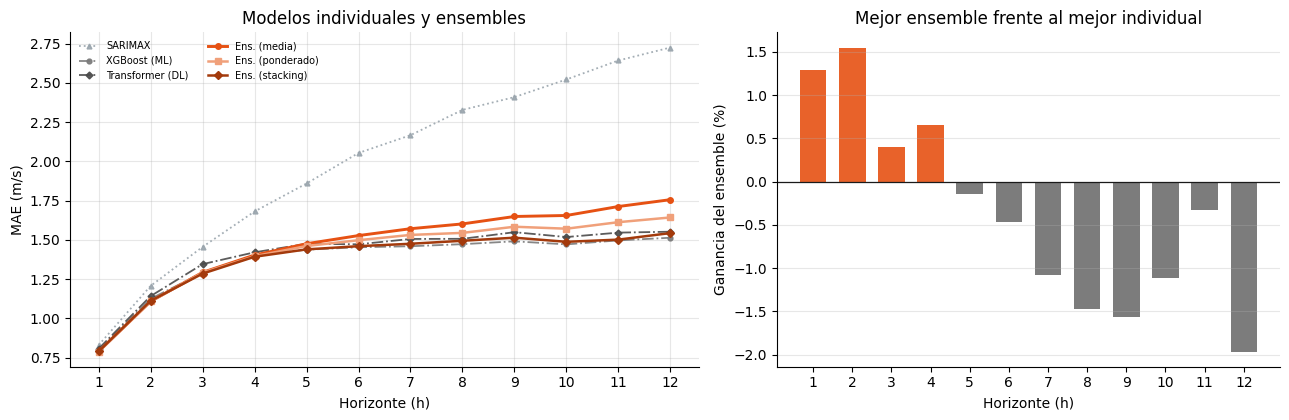

El ensemble mejora al mejor modelo individual en 4 de 12 horizontes (ganancia media cuando gana: 1.0 %).


In [7]:
resumen_ens = []
for H, e in ensembles.items():
    ev = e['evalu']
    fila = {'H': H, 'n_eval': len(ev)}
    for m in FINALISTAS:
        if m in ev.columns:
            fila[m] = mean_absolute_error(ev.REAL, ev[m])
    fila['Ensemble (media)']       = mean_absolute_error(ev.REAL, e['pred_media'])
    fila['Ensemble (ponderado)']   = mean_absolute_error(ev.REAL, e['pred_pond'])
    fila['Ensemble (stacking)']    = mean_absolute_error(ev.REAL, e['pred_stack'])
    resumen_ens.append(fila)

tabla_ens = pd.DataFrame(resumen_ens).set_index('H')
display(tabla_ens.round(3))

NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
NEGRO   = '#1A1A1A'

# Los modelos individuales se atenúan en grises y los ensembles se destacan: la
# pregunta de esta figura es si combinar mejora al mejor modelo por separado.
ESTILO_ENS = {
    'Ensemble (media)':     dict(color=NARANJA,   ls='-',  marker='o', lw=2.1),
    'Ensemble (ponderado)': dict(color='#F0A07A', ls='-',  marker='s', lw=1.8),
    'Ensemble (stacking)':  dict(color='#A33A0C', ls='-',  marker='D', lw=1.8),
}
ESTILO_IND = {
    'HARMONIE bruto':      dict(color='#BFBFBF', ls='--', marker='s', lw=1.3),
    'SARIMAX (+HARMONIE)': dict(color='#9AA5AD', ls=':',  marker='^', lw=1.3),
    MODELO_ML:             dict(color='#7A7A7A', ls='-.', marker='o', lw=1.3),
    MODELO_DL:             dict(color='#4A4A4A', ls='-.', marker='D', lw=1.3),
}

individuales = [c for c in tabla_ens.columns
                if c != 'n_eval' and not c.startswith('Ensemble')]
cols_ens = [c for c in tabla_ens.columns if c.startswith('Ensemble')]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# (a) curvas de todos los modelos
for col in individuales:
    est = ESTILO_IND.get(col, dict(color='#BFBFBF', ls='-', marker='o', lw=1.3))
    axes[0].plot(tabla_ens.index, tabla_ens[col], markersize=3.5, alpha=.9,
                 label=col.replace(' (+HARMONIE)', ''), **est)
for col in cols_ens:
    axes[0].plot(tabla_ens.index, tabla_ens[col], markersize=4,
                 label=col.replace('Ensemble ', 'Ens. '), **ESTILO_ENS[col])
axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE (m/s)')
axes[0].set_title('Modelos individuales y ensembles')
axes[0].set_xticks(list(tabla_ens.index))
axes[0].legend(ncol=2, fontsize=7, frameon=False)
axes[0].grid(alpha=.3)

# (b) ganancia del mejor ensemble sobre el mejor individual
mejor_ind = tabla_ens[individuales].min(axis=1)
mejor_ens = tabla_ens[cols_ens].min(axis=1)
ganancia = 100 * (mejor_ind - mejor_ens) / mejor_ind
colores = [NARANJA if v > 0 else GRIS for v in ganancia]
axes[1].bar(tabla_ens.index, ganancia.values, color=colores, alpha=.9, width=.68)
axes[1].axhline(0, color=NEGRO, lw=.9)
axes[1].set_xlabel('Horizonte (h)'); axes[1].set_ylabel('Ganancia del ensemble (%)')
axes[1].set_title('Mejor ensemble frente al mejor individual')
axes[1].set_xticks(list(tabla_ens.index))
axes[1].grid(axis='y', alpha=.3)

n_gana = int((ganancia > 0).sum())
for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
plt.tight_layout()

NOMBRE = 'ensembles'
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.show()

print(f'El ensemble mejora al mejor modelo individual en {n_gana} de '
      f'{len(ganancia)} horizontes '
      f'(ganancia media cuando gana: {ganancia[ganancia > 0].mean():.1f} %).')

---
## 3b. Ensemble sin SARIMAX

El test de Diebold-Mariano de la sección 4 (más abajo) mostró que XGBoost y LSTM son
estadísticamente indistinguibles, y que el ensemble de tres empeora de forma significativa a
24 h. La sospecha es que SARIMAX, mucho peor en ese horizonte, contamina la mezcla aunque
`positive=True` le limite el peso a no ser negativo.

Se repite el ensemble usando **solo XGBoost y LSTM** — dos modelos de habilidad predictiva
comparable y con errores previsiblemente menos correlados con SARIMAX que entre sí, ya que
provienen de familias distintas (árboles frente a red recurrente) mientras que SARIMAX
comparte poco mecanismo con ninguno de los dos.

In [8]:
FINALISTAS_2 = [m for m in [MODELO_ML, MODELO_DL] if m is not None]

ensembles_2 = {}
for H, piv in wide.items():
    disponibles = [m for m in FINALISTAS_2 if m in piv.columns]
    if len(disponibles) < 2:
        continue
    n = len(piv)
    corte = int(n * .5)
    calib, evalu = piv.iloc[:corte], piv.iloc[corte:]

    pred_media = evalu[disponibles].mean(axis=1)

    mae_calib = {m: mean_absolute_error(calib.REAL, calib[m]) for m in disponibles}
    pesos = {m: 1/mae_calib[m] for m in disponibles}
    suma = sum(pesos.values())
    pesos = {m: p/suma for m, p in pesos.items()}
    pred_pond = sum(evalu[m]*w for m, w in pesos.items())

    reg = Ridge(alpha=1.0, positive=True)
    reg.fit(calib[disponibles], calib.REAL)
    pred_stack = pd.Series(reg.predict(evalu[disponibles]), index=evalu.index)

    ensembles_2[H] = {'evalu': evalu, 'pesos_inv_mae': pesos,
                      'pred_media': pred_media, 'pred_pond': pred_pond, 'pred_stack': pred_stack}
    print(f'H={H} h:  pesos inv-MAE (sin SARIMAX): ' +
         ', '.join(f'{m}={w:.3f}' for m, w in pesos.items()))

resumen_ens2 = []
for H, e in ensembles_2.items():
    ev = e['evalu']
    fila = {'H': H}
    for m in FINALISTAS_2:
        fila[m] = mean_absolute_error(ev.REAL, ev[m])
    fila['Ensemble2 (media)']     = mean_absolute_error(ev.REAL, e['pred_media'])
    fila['Ensemble2 (ponderado)'] = mean_absolute_error(ev.REAL, e['pred_pond'])
    fila['Ensemble2 (stacking)']  = mean_absolute_error(ev.REAL, e['pred_stack'])
    resumen_ens2.append(fila)

tabla_ens2 = pd.DataFrame(resumen_ens2).set_index('H')
print()
display(tabla_ens2.round(3))

# Comparativa directa: ensemble de 3 (con SARIMAX) frente a ensemble de 2 (sin SARIMAX)
comp23 = pd.DataFrame({
    'Ensemble 3 (stacking, +SARIMAX)': tabla_ens['Ensemble (stacking)'],
    'Ensemble 2 (stacking, sin SARIMAX)': tabla_ens2['Ensemble2 (stacking)'],
    f'{MODELO_ML} solo': tabla_ens2[MODELO_ML],
})
print('\nComparación de las tres opciones:')
display(comp23.round(3))

H=1 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.499, Transformer (DL)=0.501
H=2 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.501, Transformer (DL)=0.499
H=3 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.500, Transformer (DL)=0.500
H=4 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.497, Transformer (DL)=0.503
H=5 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.501, Transformer (DL)=0.499
H=6 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.496, Transformer (DL)=0.504
H=7 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.496, Transformer (DL)=0.504
H=8 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.498, Transformer (DL)=0.502
H=9 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.502, Transformer (DL)=0.498
H=10 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.501, Transformer (DL)=0.499
H=11 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.504, Transformer (DL)=0.496
H=12 h:  pesos inv-MAE (sin SARIMAX): XGBoost (ML)=0.501, Transformer (DL)=0.499



,XGBoost (ML),Transformer (DL),Ensemble2 (media),Ensemble2 (ponderado),Ensemble2 (stacking)
H,,,,,
1,0.799,0.806,0.795,0.795,0.794
2,1.125,1.142,1.119,1.119,1.122
3,1.290,1.345,1.298,1.298,1.298
4,1.402,1.421,1.394,1.394,1.410
5,1.437,1.475,1.439,1.439,1.451
6,1.453,1.472,1.447,1.447,1.469
7,1.459,1.506,1.463,1.464,1.488
8,1.473,1.507,1.476,1.476,1.502
9,1.491,1.549,1.500,1.500,1.523



Comparación de las tres opciones:


,"Ensemble 3 (stacking, +SARIMAX)","Ensemble 2 (stacking, sin SARIMAX)",XGBoost (ML) solo
H,,,
1,0.790,0.794,0.799
2,1.111,1.122,1.125
3,1.285,1.298,1.290
4,1.392,1.410,1.402
5,1.439,1.451,1.437
6,1.460,1.469,1.453
7,1.475,1.488,1.459
8,1.494,1.502,1.473
9,1.514,1.523,1.491


---
## 4. Test de Diebold-Mariano

Compara si la diferencia de precisión entre dos modelos es **estadísticamente significativa**,
no solo numéricamente distinta. Se aplica sobre la serie de diferencias de pérdida:

$$d_t = g(e_{1,t}) - g(e_{2,t})$$

con `g` la función de pérdida (aquí, error absoluto) y `e_{i,t}` el error del modelo `i` en
el instante `t`. Bajo H₀ (igual precisión), `d_t` tiene media cero. El estadístico es la
media de `d_t` dividida por su error estándar, corregido por autocorrelación —los errores de
predicción a `H` horas están correlados entre sí hasta un desfase de `H-1`— con la corrección
de muestra pequeña de Harvey, Leybourne y Newbold (1997).

In [9]:
def diebold_mariano(e1, e2, h):
    """
    Test de Diebold-Mariano con corrección HLN para muestra pequeña.
    e1, e2: errores absolutos de los dos modelos, alineados en el tiempo.
    h: horizonte de predicción (define el desfase de autocorrelación a corregir).
    Devuelve (estadístico, p-valor). H0: igual precisión predictiva.
    """
    d = np.asarray(e1) - np.asarray(e2)
    n = len(d)
    d_mean = d.mean()

    # Varianza de largo plazo con autocorrelación hasta el desfase h-1
    gamma0 = np.var(d, ddof=0)
    suma_gamma = gamma0
    for k in range(1, h):
        if k >= n:
            break
        gamma_k = np.cov(d[:-k], d[k:], ddof=0)[0, 1]
        suma_gamma += 2 * gamma_k
    var_d = suma_gamma / n
    if var_d <= 0:
        return np.nan, np.nan

    dm_stat = d_mean / np.sqrt(var_d)
    # Corrección de muestra pequeña de Harvey-Leybourne-Newbold
    hln = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_stat_hln = dm_stat * hln

    p_valor = 2 * (1 - stats.t.cdf(np.abs(dm_stat_hln), df=n-1))
    return dm_stat_hln, p_valor

### Comparaciones de interés

* **XGBoost frente a SARIMAX** — ¿la ventaja del ML sobre el mejor baseline estadístico es
  significativa, o cabe dentro del ruido muestral?
* **XGBoost frente a LSTM** — la diferencia del 1-2% observada en el notebook 5b, ¿es real o
  ambos modelos son estadísticamente indistinguibles?
* **Ensemble frente al mejor individual** — ¿combinar aporta algo que ninguno de los tres
  finalistas consigue solo?
* **Mejor modelo frente a HARMONIE bruto** — la pregunta de fondo del TFM.

In [10]:
COMPARACIONES = [par for par in [
    (MODELO_ML,  'SARIMAX (+HARMONIE)'),
    (MODELO_ML,  MODELO_DL),
    (MODELO_DL,  'SARIMAX (+HARMONIE)'),
] if None not in par]

resultados_dm = []
for H in HORIZONTES:
    if H not in ensembles:
        continue
    ev = ensembles[H]['evalu']

    # Añadir el ensemble ganador (el de menor MAE en la tabla anterior) a las comparaciones
    fila_ens = tabla_ens.loc[H, ['Ensemble (media)', 'Ensemble (ponderado)', 'Ensemble (stacking)']]
    mejor_ens_nombre = fila_ens.idxmin()
    pred_mejor_ens = {'Ensemble (media)': ensembles[H]['pred_media'],
                      'Ensemble (ponderado)': ensembles[H]['pred_pond'],
                      'Ensemble (stacking)': ensembles[H]['pred_stack']}[mejor_ens_nombre]

    mejor_individual = tabla_ens.loc[H, FINALISTAS].astype(float).idxmin()

    comparaciones_h = list(COMPARACIONES)
    comparaciones_h.append((mejor_ens_nombre, mejor_individual))
    if 'HARMONIE bruto' in ev.columns:
        comparaciones_h.append((mejor_individual, 'HARMONIE bruto'))

    # Predicciones disponibles con nombre único, incluyendo el ensemble sin SARIMAX
    preds_h = {m: ev.get(m) for m in MODELOS_COMPARAR if m in ev.columns}
    preds_h[mejor_ens_nombre] = pred_mejor_ens
    if H in ensembles_2:
        ev2 = ensembles_2[H]['evalu']
        # el ensemble2 se evaluó sobre SU propia mitad; para comparar con pred_mejor_ens
        # (evaluado sobre la mitad del wide de 3 modelos) se usa el índice común de ambas
        preds_h['Ensemble2 (stacking)'] = ensembles_2[H]['pred_stack']
        comparaciones_h.append(('Ensemble2 (stacking)', mejor_individual))
        comparaciones_h.append(('Ensemble2 (stacking)', mejor_ens_nombre))

    for m1, m2 in comparaciones_h:
        pred1, pred2 = preds_h.get(m1), preds_h.get(m2)
        if pred1 is None or pred2 is None:
            continue
        # Alinear por índice común: ensemble2 puede tener una mitad de evaluación
        # ligeramente distinta si FINALISTAS_2 tuviera más filas válidas que FINALISTAS.
        idx_comun = pred1.index.intersection(pred2.index).intersection(ev.index)
        if len(idx_comun) < 30:
            continue
        e1 = (ev.REAL.loc[idx_comun] - pred1.loc[idx_comun]).abs()
        e2 = (ev.REAL.loc[idx_comun] - pred2.loc[idx_comun]).abs()
        dm_stat, p_val = diebold_mariano(e1.values, e2.values, H)
        mae1, mae2 = e1.mean(), e2.mean()
        resultados_dm.append({
            'H': H, 'modelo_1': m1, 'modelo_2': m2, 'n': len(idx_comun),
            'MAE_1': mae1, 'MAE_2': mae2, 'DM_stat': dm_stat, 'p_valor': p_val,
            'gana': m1 if (mae1 < mae2 and p_val < .05) else
                   (m2 if (mae2 < mae1 and p_val < .05) else 'sin diferencia significativa'),
        })

tabla_dm = pd.DataFrame(resultados_dm)
for H in HORIZONTES:
    if H not in ensembles:
        continue
    print(f'\n--- H={H} h ---')
    display(tabla_dm[tabla_dm.H == H].drop(columns='H').round(4))


--- H=1 h ---


,modelo_1,modelo_2,n,MAE_1,MAE_2,DM_stat,p_valor,gana
0,XGBoost (ML),SARIMAX (+HARMONIE),2358,0.7990,0.8294,-3.6150,0.0003,XGBoost (ML)
1,XGBoost (ML),Transformer (DL),2358,0.7990,0.8063,-1.3972,0.1625,sin diferencia significativa
2,Transformer (DL),SARIMAX (+HARMONIE),2358,0.8063,0.8294,-2.6590,0.0079,Transformer (DL)
3,Ensemble (ponderado),XGBoost (ML),2358,0.7887,0.7990,-2.7227,0.0065,Ensemble (ponderado)
4,XGBoost (ML),HARMONIE bruto,2358,0.7990,2.4850,-41.1186,0.0000,XGBoost (ML)
5,Ensemble2 (stacking),XGBoost (ML),2358,0.7942,0.7990,-1.7334,0.0832,sin diferencia significativa
6,Ensemble2 (stacking),Ensemble (ponderado),2358,0.7942,0.7887,1.8887,0.0591,sin diferencia significativa



--- H=2 h ---


,modelo_1,modelo_2,n,MAE_1,MAE_2,DM_stat,p_valor,gana
7,XGBoost (ML),SARIMAX (+HARMONIE),2353,1.1250,1.2067,-3.9619,0.0001,XGBoost (ML)
8,XGBoost (ML),Transformer (DL),2353,1.1250,1.1415,-1.5379,0.1242,sin diferencia significativa
9,Transformer (DL),SARIMAX (+HARMONIE),2353,1.1415,1.2067,-3.1013,0.0019,Transformer (DL)
10,Ensemble (ponderado),XGBoost (ML),2353,1.1075,1.1250,-2.0465,0.0408,Ensemble (ponderado)
11,XGBoost (ML),HARMONIE bruto,2353,1.1250,2.4946,-21.9024,0.0000,XGBoost (ML)
12,Ensemble2 (stacking),XGBoost (ML),2353,1.1219,1.1250,-0.4890,0.6249,sin diferencia significativa
13,Ensemble2 (stacking),Ensemble (ponderado),2353,1.1219,1.1075,1.9690,0.0491,Ensemble (ponderado)



--- H=3 h ---


...

,modelo_1,modelo_2,n,MAE_1,MAE_2,DM_stat,p_valor,gana
63,XGBoost (ML),SARIMAX (+HARMONIE),2108,1.4714,2.5220,-10.1223,0.0000,XGBoost (ML)
64,XGBoost (ML),Transformer (DL),2108,1.4714,1.5180,-1.5915,0.1117,sin diferencia significativa
65,Transformer (DL),SARIMAX (+HARMONIE),2108,1.5180,2.5220,-9.8808,0.0000,Transformer (DL)
66,Ensemble (stacking),XGBoost (ML),2108,1.4877,1.4714,0.6321,0.5274,sin diferencia significativa
67,XGBoost (ML),HARMONIE bruto,2108,1.4714,2.4469,-7.8864,0.0000,XGBoost (ML)
68,Ensemble2 (stacking),XGBoost (ML),2108,1.4826,1.4714,0.5124,0.6084,sin diferencia significativa
69,Ensemble2 (stacking),Ensemble (stacking),2108,1.4826,1.4877,-0.3414,0.7329,sin diferencia significativa



--- H=11 h ---


,modelo_1,modelo_2,n,MAE_1,MAE_2,DM_stat,p_valor,gana
70,XGBoost (ML),SARIMAX (+HARMONIE),2068,1.4967,2.6429,-9.9800,0.0000,XGBoost (ML)
71,XGBoost (ML),Transformer (DL),2068,1.4967,1.5462,-1.6035,0.1090,sin diferencia significativa
72,Transformer (DL),SARIMAX (+HARMONIE),2068,1.5462,2.6429,-9.7844,0.0000,Transformer (DL)
73,Ensemble (stacking),XGBoost (ML),2068,1.5017,1.4967,0.2152,0.8296,sin diferencia significativa
74,XGBoost (ML),HARMONIE bruto,2068,1.4967,2.4146,-7.2464,0.0000,XGBoost (ML)
75,Ensemble2 (stacking),XGBoost (ML),2068,1.4954,1.4967,-0.0723,0.9424,sin diferencia significativa
76,Ensemble2 (stacking),Ensemble (stacking),2068,1.4954,1.5017,-0.4884,0.6253,sin diferencia significativa



--- H=12 h ---


,modelo_1,modelo_2,n,MAE_1,MAE_2,DM_stat,p_valor,gana
77,XGBoost (ML),SARIMAX (+HARMONIE),2033,1.5137,2.7254,-9.8289,0.0000,XGBoost (ML)
78,XGBoost (ML),Transformer (DL),2033,1.5137,1.5520,-1.3872,0.1655,sin diferencia significativa
79,Transformer (DL),SARIMAX (+HARMONIE),2033,1.5520,2.7254,-10.1432,0.0000,Transformer (DL)
80,Ensemble (stacking),XGBoost (ML),2033,1.5434,1.5137,1.1294,0.2588,sin diferencia significativa
81,XGBoost (ML),HARMONIE bruto,2033,1.5137,2.4042,-6.8466,0.0000,XGBoost (ML)
82,Ensemble2 (stacking),XGBoost (ML),2033,1.5425,1.5137,1.1880,0.2350,sin diferencia significativa
83,Ensemble2 (stacking),Ensemble (stacking),2033,1.5425,1.5434,-0.0912,0.9274,sin diferencia significativa


### Cómo leer el resultado

* `DM_stat < 0` significa que el `modelo_1` tiene, en promedio, **menor** error absoluto que
  el `modelo_2`.
* `p_valor < 0.05` indica que la diferencia es estadísticamente significativa al 95%.
* La columna `gana` resume la conclusión: qué modelo es mejor **de forma significativa**, o
  si ninguno lo es (lo cual, a su vez, es información — significa que ambos son
  intercambiables en la práctica, y la elección puede basarse en otros criterios como coste
  computacional o interpretabilidad).

---
## 5. Visualización de las diferencias de error

figura guardada: figuras/dm_errores.pdf


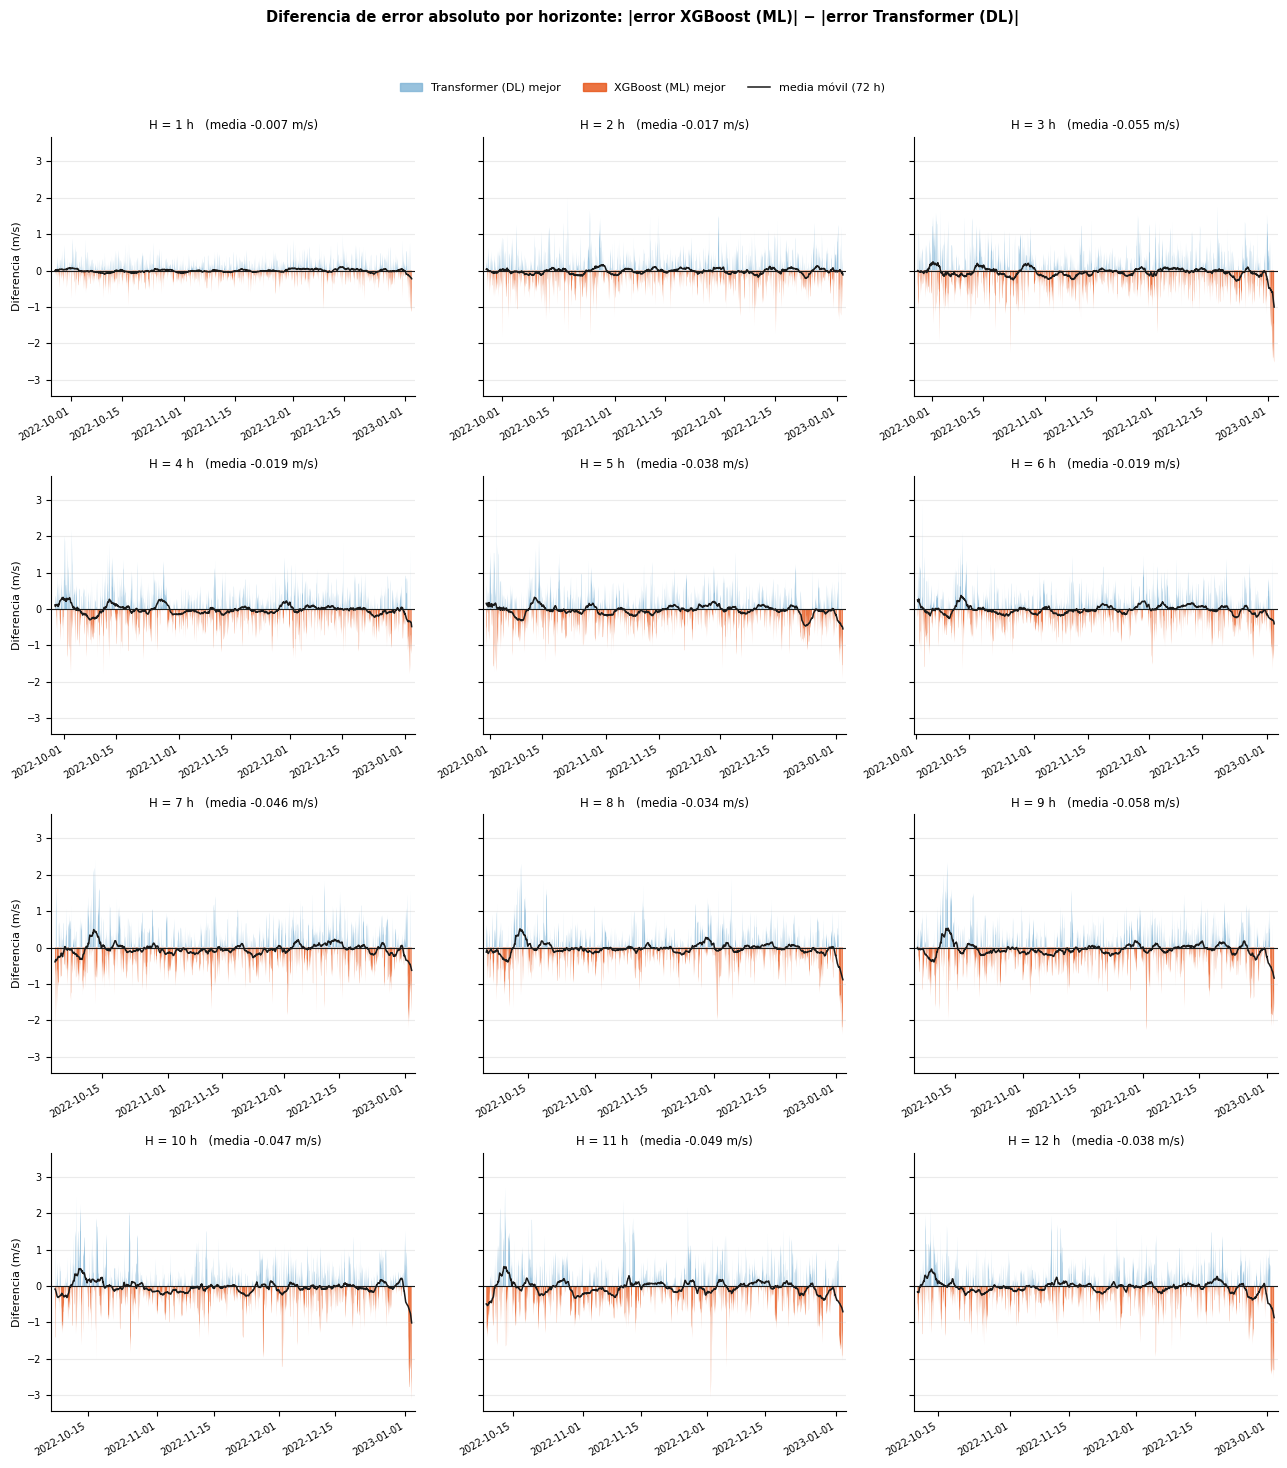

Si el área de ambos colores está equilibrada y sin patrón temporal claro,
refuerza la conclusión de que ambos modelos son intercambiables en la práctica.


In [11]:
# --- FIGURA: diferencia de error entre ML y DL a lo largo del tiempo ---------
# Si ninguna familia domina de forma sostenida, la diferencia oscila en torno a
# cero sin patrón temporal: es la lectura visual del resultado del test de
# Diebold-Mariano.
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
NEGRO   = '#1A1A1A'
AZUL    = '#7FB3D5'

hs = [h for h in sorted(ensembles)
      if MODELO_ML in ensembles[h]['evalu'].columns
      and MODELO_DL in ensembles[h]['evalu'].columns]

if not hs:
    print('No hay horizontes con ambos modelos disponibles; se omite la figura.')
else:
    # Rejilla 4x3: con doce horizontes, una sola fila resultaría ilegible.
    n_col = 3
    n_fil = int(np.ceil(len(hs) / n_col))
    fig, axes = plt.subplots(n_fil, n_col, figsize=(13, 3.5 * n_fil),
                             sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, H in zip(axes, hs):
        ev = ensembles[H]['evalu']
        d = (ev.REAL - ev[MODELO_ML]).abs() - (ev.REAL - ev[MODELO_DL]).abs()
        # Positivo: el DL acierta más que el ML en esa hora; negativo, al revés.
        ax.fill_between(d.index, 0, d.values, where=(d.values > 0),
                        color=AZUL, alpha=.8, lw=0, interpolate=True)
        ax.fill_between(d.index, 0, d.values, where=(d.values < 0),
                        color=NARANJA, alpha=.8, lw=0, interpolate=True)
        ax.axhline(0, color=NEGRO, lw=.8)
        # Media móvil: revela si existe algún sesgo sostenido en el tiempo
        ax.plot(d.index, d.rolling(72, center=True, min_periods=24).mean(),
                color=NEGRO, lw=1.1)
        media = d.mean()
        ax.set_title(f'H = {H} h   (media {media:+.3f} m/s)', fontsize=8.5)
        ax.tick_params(labelsize=7)
        ax.margins(x=0.01)
        ax.grid(axis='y', alpha=.25)
        for lado in ('top', 'right'):
            ax.spines[lado].set_visible(False)
        for etq in ax.get_xticklabels():
            etq.set_rotation(30); etq.set_ha('right')

    for ax in axes[len(hs):]:      # paneles sobrantes de la rejilla
        ax.set_visible(False)

    for i, ax in enumerate(axes[:len(hs)]):
        if i % n_col == 0:
            ax.set_ylabel('Diferencia (m/s)', fontsize=8)

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color=AZUL, alpha=.8, label=f'{MODELO_DL} mejor'),
                        Patch(color=NARANJA, alpha=.8, label=f'{MODELO_ML} mejor'),
                        plt.Line2D([], [], color=NEGRO, lw=1.1,
                                   label='media móvil (72 h)')],
               loc='upper center', ncol=3, fontsize=8, frameon=False,
               bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f'Diferencia de error absoluto por horizonte: '
                 f'|error {MODELO_ML}| − |error {MODELO_DL}|',
                 fontsize=10.5, fontweight='bold', y=1.045)
    plt.tight_layout()

    NOMBRE = 'dm_errores'
    from pathlib import Path
    Path('figuras').mkdir(exist_ok=True)
    for _fmt in ('pdf', 'png'):
        fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
    print(f'figura guardada: figuras/{NOMBRE}.pdf')

    plt.show()

print('Si el área de ambos colores está equilibrada y sin patrón temporal claro,')
print('refuerza la conclusión de que ambos modelos son intercambiables en la práctica.')

In [12]:
c = pd.read_csv('comparacion_final.csv', index_col='H')
for e in ['Ensemble (media)', 'Ensemble (ponderado)', 'Ensemble (stacking)']:
    g = 100 * (c['XGBoost (ML)'] - c[e]) / c['XGBoost (ML)']
    print(f'{e:22s} gana {int((g > 0).sum())}/12  media {g.mean():+.2f}%  máx {g.max():+.2f}%')
    

Ensemble (media)       gana 2/12  media -6.28%  máx +1.50%
Ensemble (ponderado)   gana 3/12  media -3.39%  máx +1.55%
Ensemble (stacking)    gana 4/12  media -0.39%  máx +1.21%


---
## 6. Guardado

In [13]:
tabla_final = tabla_ens.copy()
tabla_final.to_csv(RUTA/'comparacion_final.csv')

partes = []
for H, e in ensembles.items():
    ev = e['evalu']
    for nombre_e, pred_e in [('Ensemble (media)', e['pred_media']),
                             ('Ensemble (ponderado)', e['pred_pond']),
                             ('Ensemble (stacking)', e['pred_stack'])]:
        p = pred_e.rename('pred').to_frame()
        p['H'] = H; p['modelo'] = nombre_e
        p['real'] = ev.REAL
        partes.append(p.reset_index().rename(columns={'index': 'ts'}))

ens_df = pd.concat(partes, ignore_index=True)
ens_df.to_parquet(RUTA/'ensemble_predicciones.parquet', index=False)
tabla_dm.to_csv(RUTA/'diebold_mariano.csv', index=False)

print(f'Guardado comparacion_final.csv')
print(f'Guardado ensemble_predicciones.parquet: {len(ens_df)} filas')
print(f'Guardado diebold_mariano.csv: {len(tabla_dm)} comparaciones')

Guardado comparacion_final.csv
Guardado ensemble_predicciones.parquet: 79803 filas
Guardado diebold_mariano.csv: 84 comparaciones


---
## Conclusiones

**Qué llevar al capítulo de resultados:**

* La tabla de la sección 1 (tamaños de las intersecciones comunes) — declarar siempre `n`
  junto a cualquier MAE es lo que ha evitado errores serios en fases anteriores del proyecto.
* Si algún ensemble mejora de forma significativa (Diebold-Mariano, no solo numéricamente)
  al mejor modelo individual, es el resultado del objetivo 4.
* Si XGBoost y LSTM resultan estadísticamente indistinguibles, es un hallazgo tan válido
  como que uno gane: confirma con rigor estadístico lo que el análisis de interpretabilidad
  ya sugería (ambos aprenden el mismo mecanismo).
* La comparación frente a HARMONIE bruto y frente a SARIMAX cierra la pregunta central del
  TFM: cuánto y con qué certeza estadística mejora cada familia al sistema operativo actual.

**Pendiente:** notebook 7 — MLOps (MLflow, DVC, Docker, FastAPI, Evidently) y notebook 8 —
dashboard Streamlit con esquema Human-in-the-loop.